## Linear warping

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import napari

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from morphotrack import networks

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
prefix2 = {0:'prefrontal_q1_R01',1:'prefrontal_q2_R01',2:'visual_01_R01',3:'visual_02_R01'}
intensities_bundle = []
uv_bundle = []
for choice in [0,1,2,3]:
    d = np.load(os.path.join("./04_output",prefix2[choice]+"_uvt_value.npz"))
    intensities, t_grid, uv = d["intensities"], d["t_grid"], d["uv"]

    # Remove the ones with zero
    valid = intensities.sum(axis=0) != 0
    intensities = intensities[:, valid]
    uv = uv[valid, :]

    intensities_bundle.append(intensities)
    uv_bundle.append(uv)

intensities = np.hstack(intensities_bundle)
intensities = np.clip(intensities, a_min=0, a_max=np.percentile(intensities,99.5))
uv = np.vstack(uv_bundle)

T, N = intensities.shape

In [3]:
t_min, t_max = float(t_grid[0]), float(t_grid[-1])
t_num_orig   = T
dt_orig      = (t_max - t_min) / (t_num_orig - 1)

uv_min, uv_max = uv.min(0), uv.max(0)
coords_min = np.concatenate([uv_min, [t_min]])
coords_max = np.concatenate([uv_max, [t_max]])

print(f'Data: T={T}, N={N}')

uv_scattered = torch.tensor(
    (uv - uv_min) / (uv_max - uv_min + 1e-8),
    dtype=torch.float32, device=device,
)
t_norm_orig = torch.linspace(0, 1, t_num_orig, device=device)

intensity_matrix_np = intensities.T.astype(np.float64)
intensity_matrix_np = intensity_matrix_np / (intensity_matrix_np.sum(axis=1, keepdims=True) + 1e-8)
intensity_matrix    = torch.tensor(intensity_matrix_np, dtype=torch.float32, device=device)

# --- Optional t subsampling ---
t_num_data = t_num_orig
t_num      = 501
if t_num is not None and t_num < t_num_orig:
    idx_t = np.round(np.linspace(0, t_num_orig - 1, t_num)).astype(int)
    intensity_matrix_np = intensity_matrix_np[:, idx_t]
    intensity_matrix    = torch.tensor(intensity_matrix_np, dtype=torch.float32, device=device)
    t_num_orig          = t_num
    t_norm_orig         = torch.linspace(0, 1, t_num_orig, device=device)
    dt_orig             = (t_max - t_min) / (t_num_orig - 1)

print(f'N: {N}, intensity_matrix: {intensity_matrix.shape}')

Data: T=1001, N=1778
N: 1778, intensity_matrix: torch.Size([1778, 501])


In [4]:
def t_warped_from_r(r, t):                       # r: (M,), t: (T,) → (M, T)
    return t.unsqueeze(0) + r.unsqueeze(-1) * t * (t - 1)

num_freqs = 2
speed_net = networks.LinearSpeedNet(z_dim=16, hidden_dim=64, num_freqs=num_freqs, use_pos_enc=True).to(device)

In [8]:
lr            = 1e-3
n_epochs      = 2500
blur_sigma_t  = 20.0   # in t samples (was blur_sigma)
blur_sigma_uv = None   # in normalized uv units ([0,1] per axis); set to None to disable
lambda_J      = 0.0    # disabled by default; flip on if you want log(J)² regularization

optimizer = torch.optim.AdamW(speed_net.parameters(), lr=lr, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

blur_radius = max(1, int(3 * blur_sigma_t + 0.5))
_x = torch.arange(2 * blur_radius + 1, dtype=torch.float32, device=device) - blur_radius
blur_kernel = torch.exp(-_x ** 2 / (2 * blur_sigma_t ** 2))
blur_kernel = (blur_kernel / blur_kernel.sum()).view(1, 1, -1)

# uv blur: Gaussian weights over pairwise uv distances, row-normalized.
# Constant during training (uv_scattered is fixed), so built once here.
W_uv = None
if blur_sigma_uv is not None:
    with torch.no_grad():
        d2   = torch.cdist(uv_scattered, uv_scattered).pow(2)   # (N, N)
        W_uv = torch.exp(-d2 / (2 * blur_sigma_uv ** 2))
        W_uv = W_uv / W_uv.sum(dim=1, keepdim=True)

row_idx = torch.arange(N, device=device).unsqueeze(1)

for it in range(n_epochs):
    optimizer.zero_grad()

    r        = speed_net(uv_scattered)                  # (N,) ∈ [−1, 1]
    t_warped = t_warped_from_r(r, t_norm_orig)          # (N, t_num_orig)

    # Linear interp into original intensity matrix
    t_float = t_warped * (t_num_orig - 1)
    t_low   = t_float.detach().long().clamp(0, t_num_orig - 2)
    t_high  = t_low + 1
    w_high  = (t_float - t_low.float()).clamp(0, 1)
    w_low   = 1.0 - w_high
    idx     = row_idx.expand_as(t_low)
    I_warped = w_low * intensity_matrix[idx, t_low] + w_high * intensity_matrix[idx, t_high]

    I_mat = F.conv1d(I_warped.unsqueeze(1), blur_kernel, padding=blur_radius).squeeze(1)
    if W_uv is not None:
        I_mat = W_uv @ I_mat                            # 2D Gaussian blur over uv neighbors

    # Equalize each position's weight: unit-norm rows → magnitude-independent SVD
    I_mat = I_mat / I_mat.norm(dim=1, keepdim=True).clamp(min=1e-6)
    s        = torch.linalg.svdvals(I_mat)
    loss_svd = 1 - s[0] / s.sum()

    # Optional log-Jacobian reg: J = c/L = 2r·(t − 1/2) + 1
    if lambda_J > 0.0:
        J      = 2.0 * r.unsqueeze(-1) * (t_norm_orig - 0.5) + 1.0
        loss_J = torch.log(J.clamp(min=1e-6)).pow(2).mean()
    else:
        loss_J = torch.tensor(0.0, device=device)

    loss = loss_svd + lambda_J * loss_J

    loss.backward()
    torch.nn.utils.clip_grad_norm_(speed_net.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()

    if it % 100 == 0:
        print(f"Step {it:6d}  loss: {loss.item():.6f}  svd: {loss_svd.item():.6f}  J: {loss_J.item():.6f}")


Step      0  loss: 0.415964  svd: 0.415964  J: 0.000000
Step    100  loss: 0.418408  svd: 0.418408  J: 0.000000
Step    200  loss: 0.418521  svd: 0.418521  J: 0.000000
Step    300  loss: 0.417785  svd: 0.417785  J: 0.000000
Step    400  loss: 0.418750  svd: 0.418750  J: 0.000000
Step    500  loss: 0.418049  svd: 0.418049  J: 0.000000
Step    600  loss: 0.417876  svd: 0.417876  J: 0.000000
Step    700  loss: 0.418396  svd: 0.418396  J: 0.000000
Step    800  loss: 0.417505  svd: 0.417505  J: 0.000000
Step    900  loss: 0.418422  svd: 0.418422  J: 0.000000
Step   1000  loss: 0.417388  svd: 0.417388  J: 0.000000
Step   1100  loss: 0.417008  svd: 0.417008  J: 0.000000
Step   1200  loss: 0.416949  svd: 0.416949  J: 0.000000
Step   1300  loss: 0.416819  svd: 0.416819  J: 0.000000
Step   1400  loss: 0.416482  svd: 0.416482  J: 0.000000
Step   1500  loss: 0.416498  svd: 0.416498  J: 0.000000
Step   1600  loss: 0.416406  svd: 0.416406  J: 0.000000
Step   1700  loss: 0.416199  svd: 0.416199  J: 0

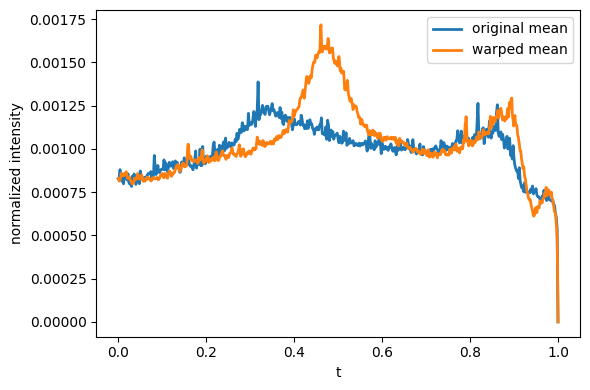

/tmp/ipykernel_1762867/2009620484.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('rainbow')((t_orig_rep - t_min) / (t_max - t_min + 1e-8))[:, :3]


<Points layer 'original pts' at 0x7fb1d4fe0ac0>

In [9]:
t_num_vis = t_num_data  # visualization t resolution; defaults to original data resolution

with torch.no_grad():
    t_norm_vis = torch.linspace(0, 1, t_num_vis, device=device)
    r_vis         = speed_net(uv_scattered)                       # (N,)
    t_warped_flat = t_warped_from_r(r_vis, t_norm_vis)            # (N, t_num_vis)

    # Warped intensity: resample from training-resolution intensity_matrix onto vis grid
    t_float = t_warped_flat * (t_num_orig - 1)
    t_low   = t_float.long().clamp(0, t_num_orig - 2)
    t_high  = t_low + 1
    w_high  = (t_float - t_low.float()).clamp(0, 1)
    row_v   = torch.arange(N, device=device).unsqueeze(1).expand_as(t_low)
    I_warped_vis = (1 - w_high) * intensity_matrix[row_v, t_low] + w_high * intensity_matrix[row_v, t_high]

    # Original intensity at vis resolution (resample from training grid)
    t_orig_float = t_norm_vis * (t_num_orig - 1)
    t_orig_low   = t_orig_float.long().clamp(0, t_num_orig - 2)
    t_orig_high  = t_orig_low + 1
    w_orig_high  = (t_orig_float - t_orig_low.float()).clamp(0, 1)
    I_orig_vis   = (1 - w_orig_high) * intensity_matrix[:, t_orig_low] + w_orig_high * intensity_matrix[:, t_orig_high]

    # Jacobian J(t) = c/L = 2r·(t − 0.5) + 1 at vis t
    r_np_v   = r_vis.cpu().numpy()                                              # (N,)
    t_vis_np = t_norm_vis.cpu().numpy()                                         # (t_num_vis,)
    J_np     = 2.0 * r_np_v[:, None] * (t_vis_np[None, :] - 0.5) + 1.0          # (N, t_num_vis)

# Profile plot: original vs warped mean
t_axis        = np.linspace(t_min, t_max, t_num_vis)
I_orig_mean   = I_orig_vis.cpu().numpy().mean(0)
I_warped_mean = I_warped_vis.cpu().numpy().mean(0)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t_axis, I_orig_mean,   label='original mean', linewidth=2)
ax.plot(t_axis, I_warped_mean, label='warped mean',   linewidth=2)
ax.set_xlabel('t'); ax.set_ylabel('normalized intensity')
ax.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# Interpolate scattered (u,v) onto a regular grid for image visualization
# ---------------------------------------------------------------------------
u_vis_num = 500
v_vis_num = 500

from scipy.interpolate import LinearNDInterpolator

u_vis_g, v_vis_g = np.meshgrid(
    np.linspace(coords_min[0], coords_max[0], u_vis_num),
    np.linspace(coords_min[1], coords_max[1], v_vis_num),
    indexing='ij'
)
uv_vis_flat = np.column_stack([u_vis_g.ravel(), v_vis_g.ravel()])

I_orig_grid   = LinearNDInterpolator(uv, I_orig_vis.cpu().numpy(),   fill_value=0)(uv_vis_flat).reshape(u_vis_num, v_vis_num, t_num_vis)
I_warped_grid = LinearNDInterpolator(uv, I_warped_vis.cpu().numpy(), fill_value=0)(uv_vis_flat).reshape(u_vis_num, v_vis_num, t_num_vis)

# J in original t space
J_orig_grid = LinearNDInterpolator(uv, J_np, fill_value=0)(uv_vis_flat).reshape(u_vis_num, v_vis_num, t_num_vis)

# J in warped t space: remap J from t_warped positions onto a uniform warped-t grid,
# then interpolate (u,v) → regular grid. t_warped_flat[i,:] is monotone since c ≥ 0.
t_warped_np      = t_warped_flat.cpu().numpy()        # (N, t_num_vis)
t_warped_uniform = np.linspace(0, 1, t_num_vis)
J_at_warped      = np.zeros((N, t_num_vis))
for i in range(N):
    J_at_warped[i] = np.interp(t_warped_uniform, t_warped_np[i], J_np[i])
J_warped_grid = LinearNDInterpolator(uv, J_at_warped, fill_value=0)(uv_vis_flat).reshape(u_vis_num, v_vis_num, t_num_vis)

# Point cloud in image pixel coordinates
def to_pixel_coords(uv, t, u_vis_num, v_vis_num, t_num_vis):
    u_px = (uv[:, 0] - coords_min[0]) / (coords_max[0] - coords_min[0] + 1e-8) * (u_vis_num - 1)
    v_px = (uv[:, 1] - coords_min[1]) / (coords_max[1] - coords_min[1] + 1e-8) * (v_vis_num - 1)
    t_px = (t        - t_min)         / (t_max          - t_min          + 1e-8) * (t_num_vis - 1)
    return np.column_stack([u_px, v_px, t_px])

t_orig          = np.linspace(t_min, t_max, t_num_vis)
t_warped_denorm = t_warped_np * (t_max - t_min) + t_min
uv_rep          = np.repeat(uv, t_num_vis, axis=0)
t_orig_rep      = np.tile(t_orig, N)
t_warped_rep    = t_warped_denorm.reshape(-1)

uvt_orig_pts   = to_pixel_coords(uv_rep, t_orig_rep,   u_vis_num, v_vis_num, t_num_vis)
uvt_warped_pts = to_pixel_coords(uv_rep, t_warped_rep, u_vis_num, v_vis_num, t_num_vis)
colors = cm.get_cmap('rainbow')((t_orig_rep - t_min) / (t_max - t_min + 1e-8))[:, :3]

viewer = napari.Viewer()
viewer.add_image(I_orig_grid,   colormap='turbo', blending='additive',    name='original')
viewer.add_image(I_warped_grid, colormap='turbo', blending='translucent', name='warped')
viewer.add_image(np.log(J_orig_grid+1e-6),   colormap='bwr', blending='translucent', name='J (orig t)',   opacity=0.6, contrast_limits=(np.log(0.5), np.log(2.0)))
viewer.add_image(np.log(J_warped_grid+1e-6), colormap='bwr', blending='translucent', name='J (warped t)', opacity=0.6, visible=False, contrast_limits=(np.log(0.5), np.log(2.0)))
viewer.add_points(uvt_warped_pts, size=0.3, face_color=colors, border_width=0, name='warped pts', visible=False)
viewer.add_points(uvt_orig_pts,   size=0.3, face_color=colors, border_width=0, name='original pts', visible=False)

In [21]:
choice = 3
cells = np.load(os.path.join("./04_output",prefix2[choice]+"_cells_slc17a7.npz"))

L = cells["L"]
uv_query = cells["uv"]
s_query  = cells["s"]
uvs = np.hstack([uv_query,s_query.reshape(-1,1)])

# 1. Normalize to [0, 1]^3 using the same coords_min/max the model was trained with
uvs_norm   = (uvs - coords_min) / (coords_max - coords_min + 1e-8)
uvs_norm_t = torch.as_tensor(uvs_norm, dtype=torch.float32, device=device)

# 2. Get per-point r(u,v), then INVERT the warp on the (normalized) s/t axis
speed_net.eval()

uv0 = uvs.copy()
uv0[:, 2] = 0
uv0_norm = (uv0 - coords_min) / (coords_max - coords_min + 1e-8)
uv0_t    = torch.as_tensor(uv0_norm, dtype=torch.float32, device=device)

# 2. r(u, v) from speed_net
speed_net.eval()
with torch.no_grad():
    r        = speed_net(uvs_norm_t[:, :2])              # (M,) per-point r(u,v)
    tw       = uvs_norm_t[:, 2]                           # (M,) normalized s, treated as t_warped

    # Solve r·t² + (1 − r)·t − tw = 0
    disc   = torch.clamp((1 - r) ** 2 + 4 * r * tw, min=0.0)
    eps    = 1e-8
    t_orig = torch.where(
        r.abs() < eps,
        tw,                                               # r ≈ 0 ⇒ identity warp
        (-(1 - r) + torch.sqrt(disc)) / (2 * r),
    ).clamp(0.0, 1.0)

    r0 = speed_net(uv0_t[:, :2]).cpu().numpy()

# 3. a and c per point
a = 2.0 * L * r0                                       # (M,) per the model: a = 2·L·r
t0 = 0
c0 = a * (t0 - 0.5) + L                                 # = L · (1 + r·(2t − 1))

# 3. Map back to physical units
s_orig = t_orig.cpu().numpy() * (coords_max[2] - coords_min[2]) + coords_min[2]

# 4. Build the un-warped point cloud
warped_cloud = uvs.copy()
warped_cloud[:, 2] = s_orig

In [7]:
viewer = napari.Viewer()
viewer.add_points(uvs*np.asarray([1.,1.,3000.]),size=30,out_of_slice_display=True,face_color='magenta')
# viewer.add_points(warped_cloud*np.asarray([1.,1.,3000.]),size=30,out_of_slice_display=True,face_color='lime')
viewer.add_points(
    warped_cloud * np.asarray([1., 1., 3000.]),
    size=30,
    out_of_slice_display=True,
    features={"c0": c0},
    face_color="c0",
    face_colormap="turbo",
    face_contrast_limits=tuple(np.percentile(c0, [1, 99])),
    name="warped (color = c0)",
)

<Points layer 'warped (color = c0)' at 0x7f1a59683c70>

In [22]:
# calculate per face c0
d = np.load(os.path.join("./04_output",prefix2[choice]+"_uvt_value_slc17a7.npz"))
verts = d['xyz']
faces = d['faces']
fid = cells["fid_mov"]

valid       = fid >= 0
Nf          = faces.shape[0]

face_sum   = np.zeros(Nf, dtype=np.float64)
face_count = np.zeros(Nf, dtype=np.int64)
np.add.at(face_sum,   fid[valid], c0[valid])     # ← sum of c0 per face
np.add.at(face_count, fid[valid], 1)             # ← count of cells per face
face_c0 = np.where(face_count > 0, face_sum / np.maximum(face_count, 1), 0.0)

np.savez_compressed(os.path.join('./05_output/', prefix2[choice]+'_uvt_warped_slc17a7.npz'),
    uvt = warped_cloud,
    c0 = c0,
    face_c0 = face_c0
)

In [9]:
has_data = face_count > 0                    # face_count from the per-face computation
vert_sum = np.zeros(verts.shape[0])
vert_cnt = np.zeros(verts.shape[0])
for k in range(3):
    np.add.at(vert_sum, faces[has_data, k], face_c0[has_data])
    np.add.at(vert_cnt, faces[has_data, k], 1)
vert_c0 = np.where(vert_cnt > 0, vert_sum / np.maximum(vert_cnt, 1), 0.0)

viewer = napari.Viewer(ndisplay=3)
viewer.add_surface((verts, faces, vert_c0),
                   name="c0", blending="translucent",
                   shading="smooth", colormap="turbo")

points = cells["xyz"]
viewer.add_points(points[::100,:],size=30,out_of_slice_display=True,face_color='magenta')

<Points layer 'Points' at 0x7f18d8cb8490>

In [10]:
torch.save({
    "state_dict": speed_net.state_dict(),
    "arch": {
        "z_dim":       16,
        "hidden_dim":  64,
        "num_freqs":   num_freqs,
        "use_pos_enc": True,
    },
    "coords_min": torch.as_tensor(coords_min, dtype=torch.float32),
    "coords_max": torch.as_tensor(coords_max, dtype=torch.float32),
    "t_num_orig": int(t_num_orig),
    "t_min":      float(t_min),
    "t_max":      float(t_max),
}, "./05_output/linear_speed_warp.pt")

In [5]:
ckpt = torch.load("./05_output/linear_speed_warp.pt",
                  map_location=device, weights_only=False)

# 2. Instantiate the model architecture and load the weights
speed_net = networks.LinearSpeedNet(**ckpt["arch"]).to(device)
speed_net.load_state_dict(ckpt["state_dict"])

<All keys matched successfully>